# Seminar 2: Exploratory Data Analysis & Visualization

Tasks based on the loanapp dataset (loan applications).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("loanapp.csv")
df.head()


,occ,loanamt,action,msa,suffolk,appinc,typur,unit,married,dep,...,approve,mortno,mortperf,mortlat1,mortlat2,chist,multi,loanprc,thick,white
0,1,89,1,1120,0,72,0,1.0,0.0,0.0,...,1,0,1,0,0,1,0.0,0.754237,0.0,1
1,1,128,3,1120,0,74,0,1.0,1.0,1.0,...,0,0,1,0,0,1,0.0,0.800000,1.0,1
2,1,128,1,1120,0,84,3,1.0,0.0,0.0,...,1,0,1,0,0,1,0.0,0.895105,1.0,1
3,1,66,1,1120,0,36,0,1.0,1.0,0.0,...,1,0,1,0,0,0,0.0,0.600000,0.0,1
4,1,120,1,1120,0,59,8,1.0,1.0,0.0,...,1,0,1,0,0,1,0.0,0.895522,0.0,1


## Task 1: Calculate the correlation between 'loanamt' (loan amount) and 'appinc' (applicant's income).

**Correct answer: 0.43**

In [2]:
correlation = df["loanamt"].corr(df["appinc"])
round(correlation, 2)


np.float64(0.43)

## Task 2: Calculate the average 'loanamt' for each 'occ' category. Which occupation has the highest average?

**Correct answer: 1**

In [3]:
mean_loan_occ = df.groupby("occ")["loanamt"].mean()
highest_mean_occ = mean_loan_occ.idxmax()
print("Average loan amount by occupation:")
print(mean_loan_occ)
print("Occupation with highest average loan amount:", highest_mean_occ)


Average loan amount by occupation:
occ
1    143.437371
2    138.588235
3    121.000000
Name: loanamt, dtype: float64
Occupation with highest average loan amount: 1


## Task 3: Find the mode (most frequent value) for the variable 'dep' (number of dependents).

**Correct answer: 0.0**

In [4]:
mode_dep = df["dep"].mode()[0]
print("Mode of dep (number of dependents):", mode_dep)


Mode of dep (number of dependents): 0.0


## Task 4: Visualize the distribution of the target variable 'action' using a bar chart.

**Correct answer: 1** (approved applications are more frequent)

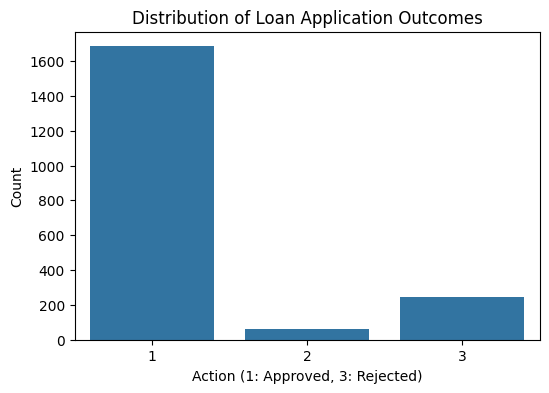

Most common action: 1


In [5]:
action_counts = df["action"].value_counts()
plt.figure(figsize=(6, 4))
sns.countplot(x="action", data=df)
plt.title("Distribution of Loan Application Outcomes")
plt.xlabel("Action (1: Approved, 3: Rejected)")
plt.ylabel("Count")
plt.show()
most_common_action = action_counts.idxmax()
print("Most common action:", most_common_action)


## Task 5: Plot a histogram for 'appinc' (applicant's income). What is the income distribution shape?

**Correct answer: right-skewed**

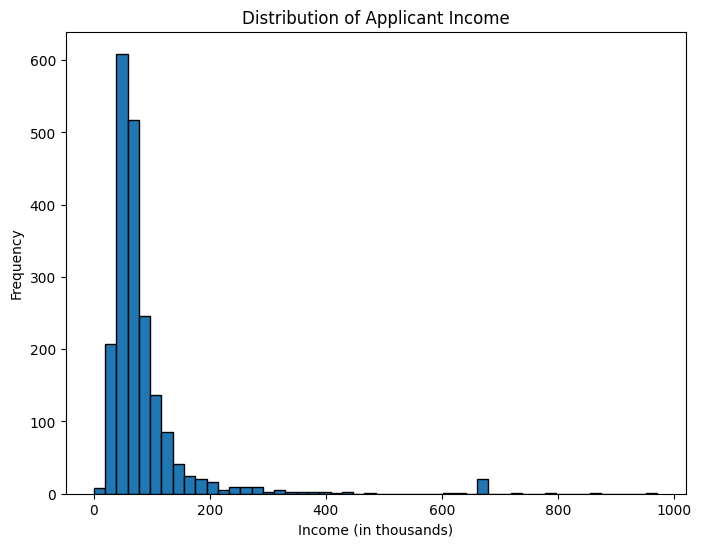

In [6]:
plt.figure(figsize=(8, 6))
plt.hist(df["appinc"], bins=50, edgecolor="k")
plt.title("Distribution of Applicant Income")
plt.xlabel("Income (in thousands)")
plt.ylabel("Frequency")
plt.show()
# The distribution is right-skewed: most applicants have lower incomes with a long tail toward higher values


## Task 6: Visualize the relationship between 'yjob' and 'loanamt' using a scatter plot. Is it linear?

**Correct answer: no**

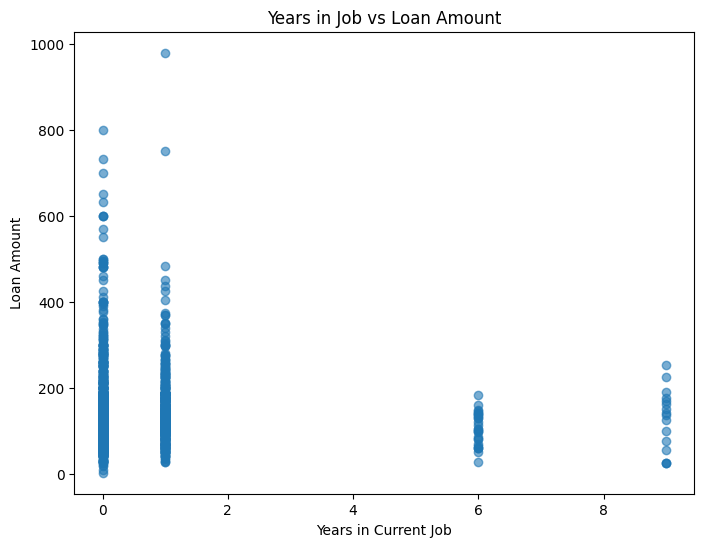

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(df["yjob"], df["loanamt"], alpha=0.6)
plt.title("Years in Job vs Loan Amount")
plt.xlabel("Years in Current Job")
plt.ylabel("Loan Amount")
plt.show()
# The relationship is NOT visually linear


## Task 7: Plot a bar plot of the average 'loanamt' over 'occ'. Which 'occ' category is at the top?

**Correct answer: 1**

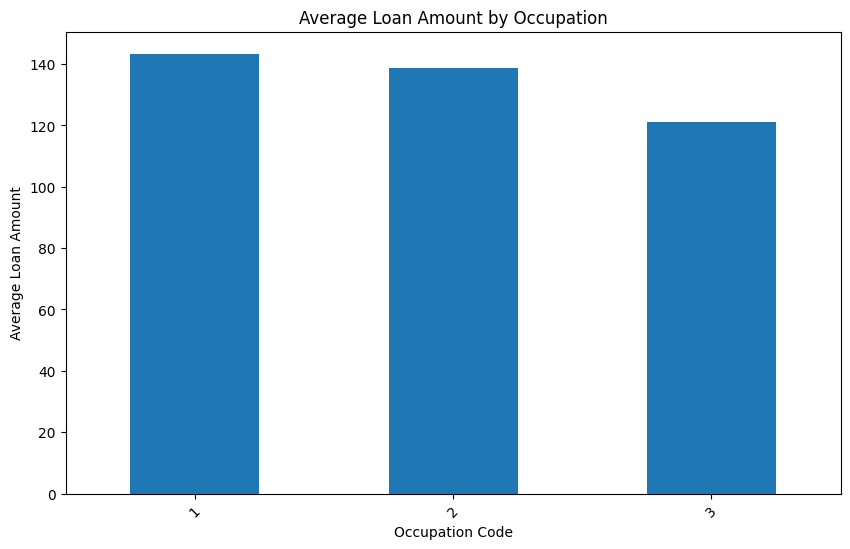

In [8]:
occ_means = df.groupby("occ")["loanamt"].mean()
plt.figure(figsize=(10, 6))
occ_means.plot(kind="bar")
plt.title("Average Loan Amount by Occupation")
plt.xlabel("Occupation Code")
plt.ylabel("Average Loan Amount")
plt.xticks(rotation=45)
plt.show()


## Task 8: Visualize the correlation between 'appinc' and 'atotinc' using a scatter plot.

**Correct answer: positive correlation**

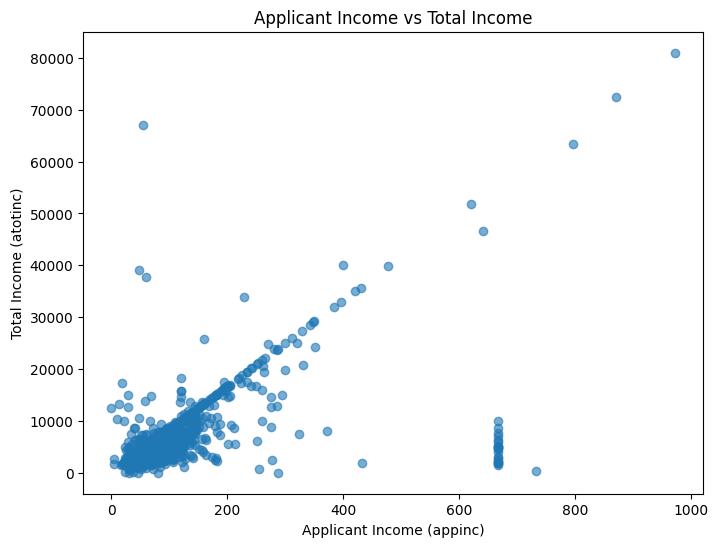

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(df["appinc"], df["atotinc"], alpha=0.6)
plt.title("Applicant Income vs Total Income")
plt.xlabel("Applicant Income (appinc)")
plt.ylabel("Total Income (atotinc)")
plt.show()
# Answer: strong positive correlation


## Task 9: Plot a box plot comparing 'obrat' for approved vs rejected applications. Which group has higher median?

**Correct answer: 3** (rejected applications have higher median obrat)

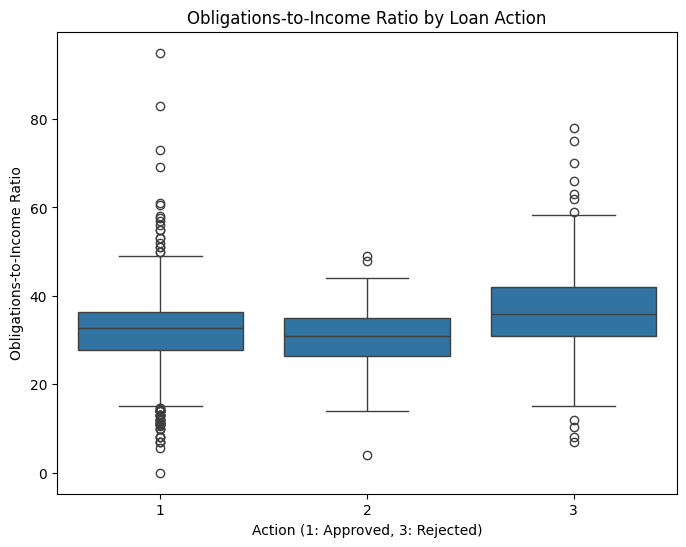

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="action", y="obrat", data=df)
plt.title("Obligations-to-Income Ratio by Loan Action")
plt.xlabel("Action (1: Approved, 3: Rejected)")
plt.ylabel("Obligations-to-Income Ratio")
plt.show()


## Task 10: Plot a stacked bar chart of marital status by gender. Which segment predominates among men?

**Correct answer: married**

married  0.0   1.0
male              
0.0      252   116
1.0      419  1184


<Figure size 800x600 with 0 Axes>

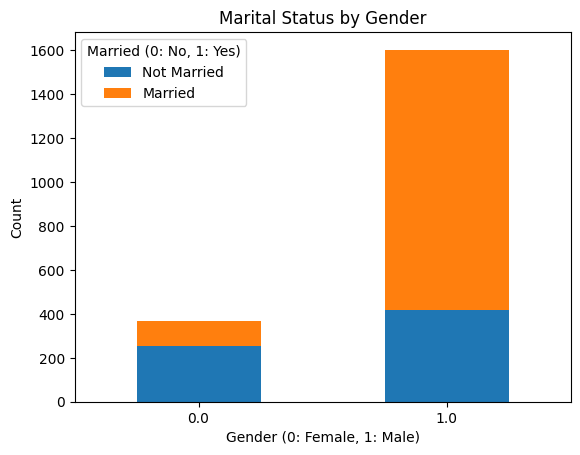

In [11]:
marital_gender_table = pd.crosstab(df["male"], df["married"])
print(marital_gender_table)

plt.figure(figsize=(8, 6))
marital_gender_table.plot(kind="bar", stacked=True)
plt.title("Marital Status by Gender")
plt.xlabel("Gender (0: Female, 1: Male)")
plt.ylabel("Count")
plt.legend(title="Married (0: No, 1: Yes)", labels=["Not Married", "Married"])
plt.xticks(rotation=0)
plt.show()
# Answer: married (married men outnumber single men)
